In [ ]:
%load_ext autoreload
%autoreload 2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from tqdm import tqdm
import pandas as pd
import sys
from typing import List
import numpy as np
import joblib
from pprint import pprint
import imodelsx.util
# import sasc.viz
import pickle as pkl
import json
from copy import deepcopy
from numpy.linalg import norm
import os
import pandas as pd
import neuro.sasc.modules.fmri_module
import imodelsx.util
from functools import partial
import numpy as np
from neuro.config import REGION_IDXS_DIR
subject = 'S02'

rois_dict = joblib.load(join(REGION_IDXS_DIR, f'rois_{subject}.jbl'))

In [ ]:
# out_dir = 'repr_steering/greedy'
out_dir = 'repr_steering/sampling_p=0.9_t=0.8'
rois = os.listdir(out_dir)
roi = 'RSC'
roi_dir = os.path.join(out_dir, roi)

In [ ]:
fnames = os.listdir(roi_dir)
fnames = sorted(fnames, key=lambda x: int(x.split('_')[-1].split('.')[0]))

# read the string in each file
generations = []
for fname in fnames:
    with open(os.path.join(roi_dir, fname), 'r') as f:
        generations.append(f.read())
# remove the longest common prefix from all generations
longest_prefix = os.path.commonprefix(generations)
generations = [gen[len(longest_prefix):] for gen in generations]
# remove quote at the start
generations = [gen[1:] if gen.startswith('"') else gen for gen in generations]

df = pd.DataFrame({'generation': generations})
df['fname'] = fnames
df['ngrams_lists'] = df['generation'].apply(partial(imodelsx.util.generate_ngrams_list, ngrams=10, pad_starting_ngrams=False))

In [ ]:
# display with no truncation
with pd.option_context('display.max_colwidth', None):
    display(df)

### Test driving

In [ ]:
mod = neuro.sasc.modules.fmri_module.fMRIModule(
    subject=f"UT{subject}",
    # checkpoint="facebook/opt-30b",
    checkpoint="huggyllama/llama-30b",
    init_model=True,
    restrict_weights=False,
)

In [ ]:
driving_vals = []
for i in tqdm(range(len(df))):
    ngrams_list = df['ngrams_lists'].iloc[i]
    if len(ngrams_list) == 0:
        break
    voxel_preds = mod(ngrams_list, return_all=True)
    vals_par = voxel_preds[:, np.array(rois_dict[roi])].mean(axis=1)
    driving_vals.append(vals_par)

In [26]:
driving_mean_vals = [np.mean(vals) for vals in driving_vals]

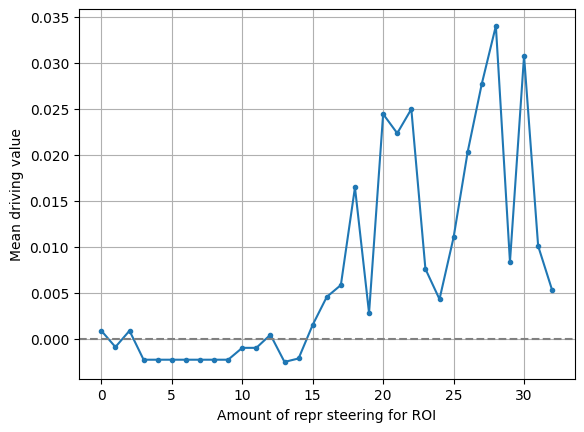

In [33]:
plt.plot(driving_mean_vals, '.-')
plt.axhline(y=0, color='gray', linestyle='--')
plt.ylabel('Mean driving value')
plt.xlabel('Amount of repr steering for ROI')
plt.grid()

In [32]:
df

,generation,fname,ngrams_lists
0,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_100.00.txt,"[A man walks into a bar, carrying a pig under,..."
1,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_119.38.txt,"[A man walks into a bar, carrying a pig under,..."
2,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_142.51.txt,"[A man walks into a bar, carrying a pig under,..."
3,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_170.13.txt,"[A man walks into a bar, carrying a pig under,..."
4,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_203.09.txt,"[A man walks into a bar, carrying a pig under,..."
5,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_242.45.txt,"[A man walks into a bar, carrying a pig under,..."
6,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_289.43.txt,"[A man walks into a bar, carrying a pig under,..."
7,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_345.51.txt,"[A man walks into a bar, carrying a pig under,..."
8,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_412.46.txt,"[A man walks into a bar, carrying a pig under,..."
9,"A man walks into a bar, carrying a pig under h...",generated_paragraph_steered_492.39.txt,"[A man walks into a bar, carrying a pig under,..."


In [35]:
df.iloc[28].generation

'A man who was killed in Paris on jan. 1, where everybody is still a year ago in the south of texas, a small town where everyone is still a year ago in the east of texas, and i am in a different state, a city where i have been for a while, a couple of years later, i am still in the same place, a day when i am in the same place, a place where i am in the same place, a city where i am'